In [1]:
import numpy as np
from numba import jit, prange
import matplotlib.pyplot as plt
import scipy
from scipy.fft import rfft, irfft, fftshift, ifftshift
from tqdm import tqdm

In [2]:
@jit(nopython=True, cache=True)
def _buffer(x, out, nfft, hop_len):
    for i in prange(0, x.shape[-1]-nfft+1, hop_len):
        out[:,:,i]=x[:,i:i+nfft]
def buffer(x, nfft, hop_len, modulated=True):
    # x: channel, time
    if np.ndim(x)==1:
        x = x.reshape(1,-1)
    out = np.zeros((x.shape[0], nfft, x.shape[-1]-nfft+1))
    _buffer(x, out, nfft, hop_len)
    if modulated:
        out = np.roll(out, int(np.ceil(nfft / 2)), 1)
    return out

@jit(nopython=True, cache=True)
def _unbuffer(x, xbuf, window, hop_len):
    for i in prange(xbuf.shape[2]):
        n = i * hop_len
        x[:, n:n + len(window)] += xbuf[:, :, i] * window
        
def unbuffer(xbuf, window, hop_len, win_exp=1):
    if np.ndim(xbuf)==2:
        xbuf=np.expand_dims(xbuf,0)
    if win_exp == 0:
        window = 1
    elif win_exp != 1:
        window = window ** win_exp
    x = np.zeros((xbuf.shape[0], xbuf.shape[1] + xbuf.shape[2] - 1), dtype=xbuf.dtype)

    _unbuffer(x, xbuf, window, hop_len)
    return x

@jit(nopython=True, cache=True)
def _window_norm(wn, window, hop_len, n_fft, win_exp=1):
    max_hops = (len(wn) - n_fft) // hop_len + 1
    wpow = window ** (win_exp + 1)
    for i in range(max_hops):
        n = i * hop_len
        wn[n:n + n_fft] += wpow

def window_norm(window, hop_len, n_fft, N, win_exp=1):
    wn = np.zeros(N + n_fft - 1)
    _window_norm(wn, window, hop_len, n_fft, win_exp)
    return wn

In [3]:
class VMD(object):
    def __init__(self, num_channel, n_fft= 128, alpha= 10, K= 3, init=1, tol=1e-05, tau= 0.1, maxiters=1000) -> None:
        self.alpha = alpha*np.ones(K)
        self.K=K
        self.n_fft = n_fft
        self.init=init
        self.tol=tol
        self.tau=tau
        self.maxiters = maxiters
        self.padwidth = ((n_fft-1)//2, (n_fft-1)//2) if (n_fft-1)%2==0 else ((n_fft-1)//2+1, (n_fft-1)//2)
        self.num_channel = num_channel
        self.u_hat_plus = None
        self.sum_uk = None
    
    def prepare_offline(self, x):
        assert np.ndim(x)<=2
        if np.ndim(x)==1:
            x = x.reshape(1, -1)
        self.len_x = x.shape[1]
        xp = np.pad(x, ([0, 0], self.padwidth), mode='reflect')
        f_hat_plus = rfft(xp, axis=1, workers=-1)
        return f_hat_plus
    
    def apply(self, f_hat_plus, omega=None):
        C, len_freqs = f_hat_plus.shape
        freqs = np.arange(1, len_freqs+1)/(len_freqs)
        omega_plus = np.zeros([self.maxiters, self.K])
        if omega is None:
            for i in range(self.K):
                omega_plus[0,i] = (1/self.K)*i
        else:
            omega_plus[0] = omega.ravel()
 
        u_hat_plus = np.zeros([self.maxiters, C, len_freqs, self.K],dtype=complex)
        sum_uk = np.zeros([C, len_freqs], dtype=complex)
        lambda_hat = np.zeros([self.maxiters, C, len_freqs], dtype = complex)
        
        pbar = tqdm(np.arange(self.maxiters-1))
        for iter in pbar:
            # n = np.mod(iter, 2)
            
            k = 0
            for c in np.arange(C):
                sum_uk[c,:] = u_hat_plus[np.mod(iter, 2), c,:,self.K-1] + sum_uk[c,:] - u_hat_plus[np.mod(iter, 2), c,:,0]
                u_hat_plus[np.mod(iter+1, 2), c,:,k] = (f_hat_plus[c, :] - sum_uk[c,:] - lambda_hat[np.mod(iter, 2), c,:]/2)/(1.+self.alpha[k]*(freqs - omega_plus[np.mod(iter, 2),k])**2)
            for k in np.arange(1,self.K):
                for c in np.arange(C):
                    sum_uk[c,:] = u_hat_plus[np.mod(iter+1, 2),c,:,k-1] + sum_uk[c,:] - u_hat_plus[np.mod(iter, 2),c,:,k]
                    u_hat_plus[np.mod(iter+1, 2),c,:,k] = (f_hat_plus[c,:] - sum_uk[c,:] - lambda_hat[np.mod(iter, 2),c,:]/2)/(1+self.alpha[k]*(freqs - omega_plus[np.mod(iter, 2),k])**2)
                # center frequencies
                if omega is not None:
                    omega_plus[np.mod(iter+1, 2),k] = omega_plus[0,k]
                else:
                    omega_plus[np.mod(iter+1, 2),k] = np.sum(np.einsum('j,ij', freqs,(abs(u_hat_plus[np.mod(iter+1, 2), :, :, k])**2)))/np.sum(abs(u_hat_plus[np.mod(iter+1, 2),:,:,k])**2)
            lambda_hat[np.mod(iter+1, 2),:,:] = lambda_hat[np.mod(iter, 2),:,:] + self.tau*(np.sum(u_hat_plus[np.mod(iter+1, 2),:,:,:],axis = 2)-f_hat_plus)

            uDiff = np.spacing(np.ones(self.K))
            for i in range(self.K):
                delta = u_hat_plus[0,:,i]-u_hat_plus[1,:,i]
                delta = delta.reshape(-1)
                uDiff[i] = (1/len(delta))*np.dot(delta,np.conj(delta)).real
            # for i in range(self.K):
            #     uDiff = uDiff + np.power(u_hat_plus[np.mod(iter, 2)]-u_hat_plus[np.mod(iter-1, 2)], 2).sum()/(len_freqs*self.K*C)
            uDiff = uDiff.mean(-1)
            if uDiff < self.tol and iter>2:
                break
            pbar.set_description("Processing "  + "{:10.9f}".format(uDiff) + ":")
        u_hat = u_hat_plus[np.mod(iter, 2)]
        omega = omega_plus[np.mod(iter, 2)]
        seqw = np.argsort(omega)
        u_hat = u_hat[:,:,seqw]
        omega = omega[seqw]
        return u_hat, omega
    
    def postprocess(self, u_hat):
        u = irfft(u_hat, n=self.len_x+np.sum(self.padwidth), axis=1, workers=-1).real
        u = np.transpose(u, (2, 0, 1))
        u = u[:, :, self.padwidth[0]:-self.padwidth[1]]
        return u

In [4]:
class STVMD(object):
    def __init__(self, num_channel, n_fft= 128, cache_size=None, window_func=None, alpha= 10, K= 3, init=1, tol=1e-05, tau= 0.1, win_exp=1, maxiters=1000) -> None:
        # n_fft: odd integers
        self.hop_len = 1
        self.n_fft = n_fft
        self.win_len = n_fft
        self.alpha = alpha*np.ones(K)
        self.freqs = np.arange(1, n_fft//2+2)/(n_fft//2+1)
        self.K=K
        self.win_exp = win_exp
        self.init=init
        self.tol=tol
        self.tau=tau
        self.padwidth = ((n_fft-1)//2, (n_fft-1)//2) if (n_fft-1)%2==0 else ((n_fft-1)//2+1, (n_fft-1)//2)
        if window_func is None:
            self.window = scipy.signal.windows.dpss(self.win_len, max(4, self.win_len//8), sym=False)
        else:
            self.window = window_func
        self.maxiters = maxiters

        self.num_channel = num_channel
        
        if cache_size is None:
            self.cache_size = self.n_fft
        else:
            self.cache_size = cache_size
        self.buffer_cache = np.zeros((self.num_channel, self.cache_size))# channel, F, T
        self.u_hat_cache = np.zeros((self.num_channel, len(self.freqs), self.K, self.cache_size)) # C, len(self.freqs), self.K, N
        self.u_hat_plus = None
        self.sum_uk = None
    
    def prepare_online(self, x):
        assert np.ndim(x)<=2
        if np.ndim(x)==1:
            x = x.reshape(-1, 1)
        new_dims = x.shape[-1]
        self.buffer_cache = np.roll(self.buffer_cache, -new_dims, axis=1)
        self.buffer_cache[:,-new_dims:]=x
        xp = np.pad(self.buffer_cache, ([0, 1], [0, (self.n_fft-1)//2]), mode='reflect')
        Sx = buffer(xp, self.n_fft, self.hop_lenp.mod(iter, 2), modulated=False)
        # Sx *= ifftshift(self.window, axes=0).reshape((1, -1, 1))
        Sx *= self.window.reshape((1, -1, 1))
        f_hat_plus = rfft(Sx, axis=1, workers=-1)
        return f_hat_plus
    
    def prepare_offline(self, x):
        assert np.ndim(x)<=2
        if np.ndim(x)==1:
            x = x.reshape(1, -1)
        # assert x.shape[-1]>=self.n_fft
        xp = np.pad(x, ([0, 0], self.padwidth), mode='reflect')
        self.buffer_cache = xp[:, -self.n_fft//2+1-self.n_fft:-self.n_fft//2+1]
        Sx = buffer(xp, self.n_fft, self.hop_len, modulated=False)
        # Sx *= ifftshift(self.window, axes=0).reshape((1, -1, 1))
        Sx *= self.window.reshape((1, -1, 1))
        f_hat_plus = rfft(Sx, axis=1, workers=-1)
        return f_hat_plus, Sx
    
    def apply(self, f_hat_plus, omega=None, dynamic=False):
        if dynamic:
            u_hat, omega = self.apply_dynamic(f_hat_plus)
        else:
            u_hat, omega = self.apply_nodynamic(f_hat_plus, omega)
        return u_hat, omega
    
    def apply_nodynamic(self, f_hat_plus, omega=None, cached=False):
        C, _, N = f_hat_plus.shape
        omega_plus = np.zeros([self.maxiters, self.K])
        if omega is None:
            for i in range(self.K):
                omega_plus[0,i] = (1/self.K)*i
        else:
            omega_plus[0,:] = omega.reshape(-1,1)
        
        if cached:
            u_hat_plus = np.zeros([2, C, len(self.freqs), self.K, N],dtype=complex)
            u_hat_plus[0,:,:,:,:-1]=self.u_hat_cache[:,:,:,1:]
        else:
            u_hat_plus = np.zeros([2, C, len(self.freqs), self.K, N],dtype=complex)
        sum_uk = np.zeros([N, C, len(self.freqs)], dtype=complex)
        lambda_hat = np.zeros([2, C, len(self.freqs), N], dtype = complex)
        
        pbar = tqdm(np.arange(self.maxiters-1))
        for iter in pbar:
            # n = np.mod(iter, 2)
            
            k = 0
            for c in np.arange(C):
                for sw in np.arange(N):
                    sum_uk[sw,c,:] = u_hat_plus[np.mod(iter, 2), c,:,self.K-1,sw] + sum_uk[sw, c,:] - u_hat_plus[np.mod(iter, 2), c,:,0, sw]
                    u_hat_plus[np.mod(iter+1, 2), c,:,k, sw] = (f_hat_plus[c, :, sw] - sum_uk[sw, c,:] - lambda_hat[np.mod(iter, 2), c,:,sw]/2)/(1.+self.alpha[k]*(self.freqs - omega_plus[np.mod(iter, 2),k])**2)
            for k in np.arange(1,self.K):
                for sw in np.arange(N):
                    for c in np.arange(C):
                        #accumulator
                        sum_uk[sw,c,:] = u_hat_plus[np.mod(iter+1, 2),c,:,k-1,sw] + sum_uk[sw,c,:] - u_hat_plus[np.mod(iter, 2),c,:,k,sw]
                        # mode spectrum
                        u_hat_plus[np.mod(iter+1, 2),c,:,k,sw] = (f_hat_plus[c,:,sw] - sum_uk[sw,c,:] - lambda_hat[np.mod(iter, 2),c,:,sw]/2)/(1+self.alpha[k]*(self.freqs - omega_plus[np.mod(iter, 2),k])**2)
                # center frequencies
                if omega is not None:
                    omega_plus[np.mod(iter+1, 2),k] = omega_plus[0,k]
                else:
                    omega_plus[np.mod(iter+1, 2),k] = np.sum(np.einsum('j,ijk', self.freqs,(abs(u_hat_plus[np.mod(iter+1, 2), :, :, k, :])**2)))/np.sum(abs(u_hat_plus[np.mod(iter+1, 2),:,:,k,:])**2)
            lambda_hat[np.mod(iter+1, 2),:,:,:] = lambda_hat[np.mod(iter, 2),:,:,:] + self.tau*(np.sum(u_hat_plus[np.mod(iter+1, 2),:,:,:,:],axis = 2)-f_hat_plus)
            
            uDiff = np.spacing(np.ones((C, N, self.K)))
            for i in range(self.K):
                for c in range(C):
                    for n in range(N):
                        delta = u_hat_plus[0,c,:,i,n]-u_hat_plus[1,c,:,i, n]
                        delta = delta.reshape(-1)
                        uDiff[c,n,i] = (1/len(delta))*np.dot(delta,np.conj(delta)).real
            uDiff = uDiff.mean(-1)
            uDiff = uDiff.max()
            if uDiff < self.tol and iter>2:
                break
            pbar.set_description("Processing "  + "{:10.9f}".format(uDiff) + ":")
        u_hat = u_hat_plus[np.mod(iter, 2)]
        omega = omega_plus[np.mod(iter, 2)]
        self.u_hat_cache = u_hat_plus[np.mod(iter, 2), :, :, :, -self.cache_size:]
        seqw = np.argsort(omega)
        u_hat = u_hat[:,:,seqw,:]
        omega = omega[seqw]
        return u_hat, omega
    
    def apply_dynamic(self, f_hat_plus, cached=False):
        C, F, N = f_hat_plus.shape
        freqs = np.arange(1, F+1)/F# self.freqs
        omega_plus = np.zeros([self.maxiters, self.K, N])
        for i in range(self.K):
            omega_plus[0,i,:] = (1/self.K)*i
            
        if cached:
            u_hat_plus = np.zeros([2, C, len(freqs), self.K, N],dtype=complex)
            u_hat_plus[0,:,:,:,:-1]=self.u_hat_cache[:,:,:,1:]
        else:
            u_hat_plus = np.zeros([2, C, len(freqs), self.K, N],dtype=complex)
        sum_uk = np.zeros([N, C, len(freqs)], dtype=complex)
        lambda_hat = np.zeros([2, C, len(freqs), N], dtype = complex)
        
        pbar = tqdm(np.arange(self.maxiters-1))
        for iter in pbar:
            # n = np.mod(iter, 2)
            
            k = 0
            for c in np.arange(C):
                for sw in np.arange(N):
                    sum_uk[sw,c,:] = u_hat_plus[np.mod(iter, 2), c,:,self.K-1,sw] + sum_uk[sw, c,:] - u_hat_plus[np.mod(iter, 2), c,:,0, sw]
                    u_hat_plus[np.mod(iter+1, 2), c,:,k, sw] = (f_hat_plus[c, :, sw] - sum_uk[sw, c,:] - lambda_hat[np.mod(iter, 2), c,:,sw]/2)/(1.+self.alpha[k]*(freqs - omega_plus[np.mod(iter, 2),k, sw])**2)
            for k in np.arange(1,self.K):
                for sw in np.arange(N):
                    for c in np.arange(C):
                        #accumulator
                        sum_uk[sw,c,:] = u_hat_plus[np.mod(iter+1, 2),c,:,k-1,sw] + sum_uk[sw,c,:] - u_hat_plus[np.mod(iter, 2),c,:,k,sw]
                        # mode spectrum
                        
                        u_hat_plus[np.mod(iter+1, 2),c,:,k,sw] = (f_hat_plus[c,:,sw] - sum_uk[sw,c,:] - lambda_hat[np.mod(iter, 2),c,:,sw]/2)/(1+self.alpha[k]*(freqs - omega_plus[np.mod(iter, 2),k, sw])**2)
                        # center frequencies
                    omega_plus[np.mod(iter+1, 2),k,sw] = np.sum(np.einsum('j,ij', freqs,(abs(u_hat_plus[np.mod(iter+1, 2), :, :, k, sw])**2)))/np.sum(abs(u_hat_plus[np.mod(iter+1, 2),:,:,k,sw])**2)
            lambda_hat[np.mod(iter+1, 2),:,:,:] = lambda_hat[np.mod(iter, 2),:,:,:] + self.tau*(np.sum(u_hat_plus[np.mod(iter+1, 2),:,:,:,:],axis = 2)-f_hat_plus)
            uDiff = np.spacing(np.ones((C, N, self.K)))
            for i in range(self.K):
                for c in range(C):
                    for n in range(N):
                        delta = u_hat_plus[0,c,:,i,n]-u_hat_plus[1,c,:,i, n]
                        delta = delta.reshape(-1)
                        uDiff[c,n,i] = (1/len(delta))*np.dot(delta,np.conj(delta)).real
            uDiff = uDiff.mean(-1)
            uDiff = uDiff.max()
            if uDiff < self.tol and iter>2:
                break
            pbar.set_description("Processing "  + "{:10.9f}".format(uDiff) + ":")
        u_hat = u_hat_plus[np.mod(iter, 2)]
        self.u_hat_cache = u_hat_plus[np.mod(iter, 2), :, :, :, -self.cache_size:]
        omega = omega_plus[np.mod(iter, 2)]
        seqw = np.argsort(omega, axis=0)
        for n in range(N):
            u_hat[:,:,:,n] = u_hat[:,:,seqw[:,n],n]
            omega[:,n] = omega[seqw[:,n],n]
        # remove the bias induced by the setting of self.freqs
        # omega[1:,n] = omega[1:,n]-1/(self.n_fft//2+1)
        return u_hat, omega
    
    def postprocess(self, u_hat):
        u = np.zeros([self.K, u_hat.shape[0], u_hat.shape[-1]+np.sum(self.padwidth)])
        wn = window_norm(self.window, self.hop_len, self.n_fft, u_hat.shape[-1], self.win_exp)
        for k in range(self.K):
            xbuf = irfft(u_hat[:,:,k,:], n=self.n_fft, axis=1, workers=-1).real
            # xbuf = fftshift(xbuf, axes=0)
            u[k,:,:] = unbuffer(xbuf, self.window, self.hop_len, self.win_exp)
        u = u/wn.reshape(1,1,-1)

        u = u[:, :, self.padwidth[0]:-self.padwidth[1]]
        return u

In [5]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
data=loadmat('sample.mat')['eeg']
mdata = data.mean(-1)
t=np.arange(250*5)/250

In [6]:
mdata.shape
f = np.concatenate((mdata[2,7,:], mdata[5,7,:]), axis=-1)
f = f/f.max()

In [7]:
imf_stvmd_d = []
imf_stvmd_nd = []
f_hat = []
nfft = 250
N_imfs = 3
N_channels = 1
alpha = 50

In [8]:
vmd = VMD(num_channel=N_channels, alpha=alpha, n_fft=64, K=N_imfs, tol=1e-9, tau=0.00001, maxiters=10000)
f_hat_v = vmd.prepare_offline(f)
u_hat_v, w_hat_v = vmd.apply(f_hat_v)

Processing 0.000000000::   0%|          | 3/9999 [00:00<00:20, 499.64it/s]


In [9]:
window_func = scipy.signal.windows.hamming(nfft, sym=False)
stmd = STVMD(num_channel=N_channels, window_func=window_func, alpha=alpha, n_fft=nfft, K=N_imfs, tol=1e-9, tau=0.00001, maxiters=2000)
f_hat_s, b_hat_s = stmd.prepare_offline(f)

In [10]:
fsig = np.abs(f_hat_s[0][:,:]).mean(-1)

In [11]:
fsig.shape

(126,)

In [12]:
pfig = np.pad(fsig, [2, 2], 'reflect') 

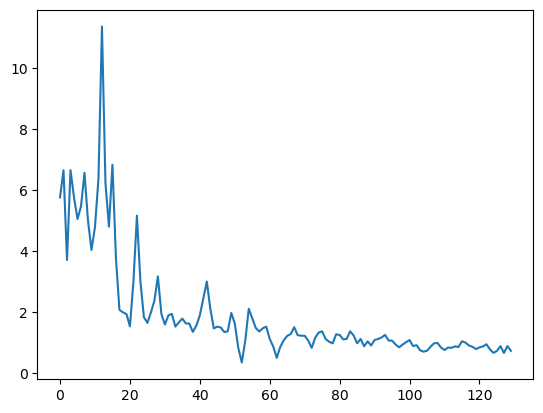

In [13]:
plt.plot(pfig)

In [14]:
def average_min(fsig, win_len=5):
    msig = np.zeros_like(fsig)
    pfsig = np.pad(fsig, [win_len//2, win_len//2], 'reflect')
    for i in range(len(msig)):
        msig[i]=min(pfsig[i:i+win_len])
    return msig

In [15]:
msig = np.zeros_like(fsig)

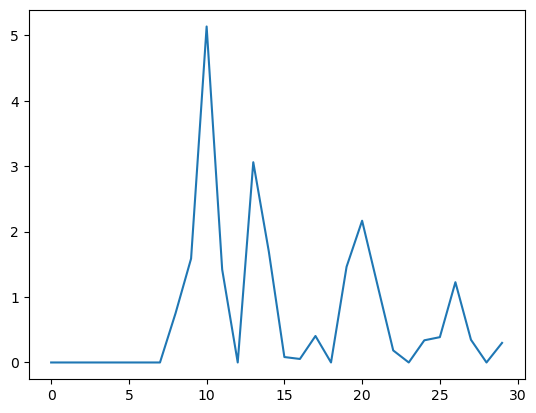

In [16]:
msig = average_min(fsig, win_len=3)
esig = fsig-msig
esig[:8]=0
esig[30:]=0
plt.plot(esig[:30])

In [17]:
imf_stvmd_d = []
imf_stvmd_nd = []
f_hat = []
nfft = 250
N_imfs = 3
N_channels = 1
alpha = 50

In [18]:
f_hat_s.shape

(1, 126, 2500)

In [19]:
from PyEMD import EMD

In [20]:
N_imfs=3
vmd = VMD(num_channel=N_channels, alpha=alpha, n_fft=64, K=N_imfs, tol=1e-9, tau=0.00001, maxiters=10000)
f_hat_v = vmd.prepare_offline(f)
for i in range(N_channels):
    msig = average_min(f_hat_v[i], win_len=5)
    f_hat_v[i] = np.maximum(0,f_hat_v[i].reshape(-1)-msig.reshape(-1))
f_hat_v[:, 300:]=np.finfo(np.float64).eps
f_hat_v[:, :80]=np.finfo(np.float64).eps
u_hat_v, w_hat_v = vmd.apply(f_hat_v)
imf_vmd = vmd.postprocess(u_hat_v)

Processing 0.000000000::   0%|          | 3/9999 [00:00<00:13, 750.10it/s]


In [21]:
f_emd = vmd.postprocess(f_hat_v.reshape(1,-1,1))

In [22]:
emd = EMD(extrema_detection='parabol')
IMFs = emd.emd(f_emd.ravel())
imf_emd = IMFs[:3, :]
imf_emd[-1,:]=IMFs[2:].sum(0)

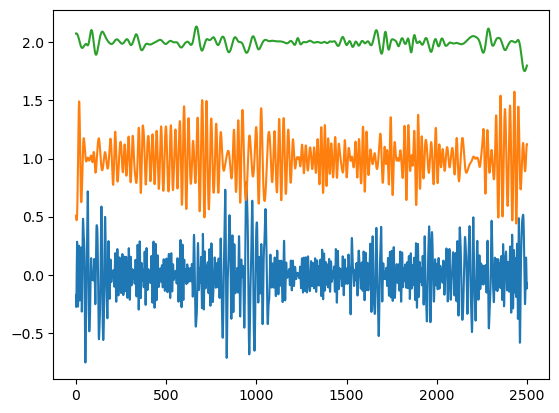

In [23]:
plt.plot(imf_emd.T+np.arange(3).reshape(1, -1))

In [24]:
N_imfs = 3

In [25]:
window_func = scipy.signal.windows.hamming(nfft, sym=False)
stmd = STVMD(num_channel=N_channels, window_func=window_func, alpha=alpha, n_fft=nfft, K=N_imfs, tol=1e-9, tau=0.00001, maxiters=2000)
f_hat_s, b_hat_s = stmd.prepare_offline(f)

for i in range(N_channels):
    fsig = np.abs(f_hat_s[i][:,:]).mean(-1)
    msig = average_min(fsig, win_len=5)
    f_hat_s[i] = np.maximum(0,f_hat_s[i]-msig.reshape(-1,1))
if np.ndim(f_hat_s)==2:
    f_hat_s = np.expand_dims(f_hat_s, 0)
f_hat_s[:, 30:,:]=np.finfo(np.float64).eps
f_hat_s[:, :8,:]=np.finfo(np.float64).eps
u_hat_d, w_hat_d = stmd.apply(f_hat_s, dynamic=True)
imf_stvmd_d = stmd.postprocess(u_hat_d)

u_hat_nd, w_hat_nd = stmd.apply(f_hat_s, dynamic=False)
imf_stvmd_nd = stmd.postprocess(u_hat_nd)

Processing 0.000000001::   3%|▎         | 53/1999 [00:06<04:10,  7.76it/s]


In [26]:
mode = [' Residual at 0 Hz', 'Mode Function 1', 'Mode Function 2']

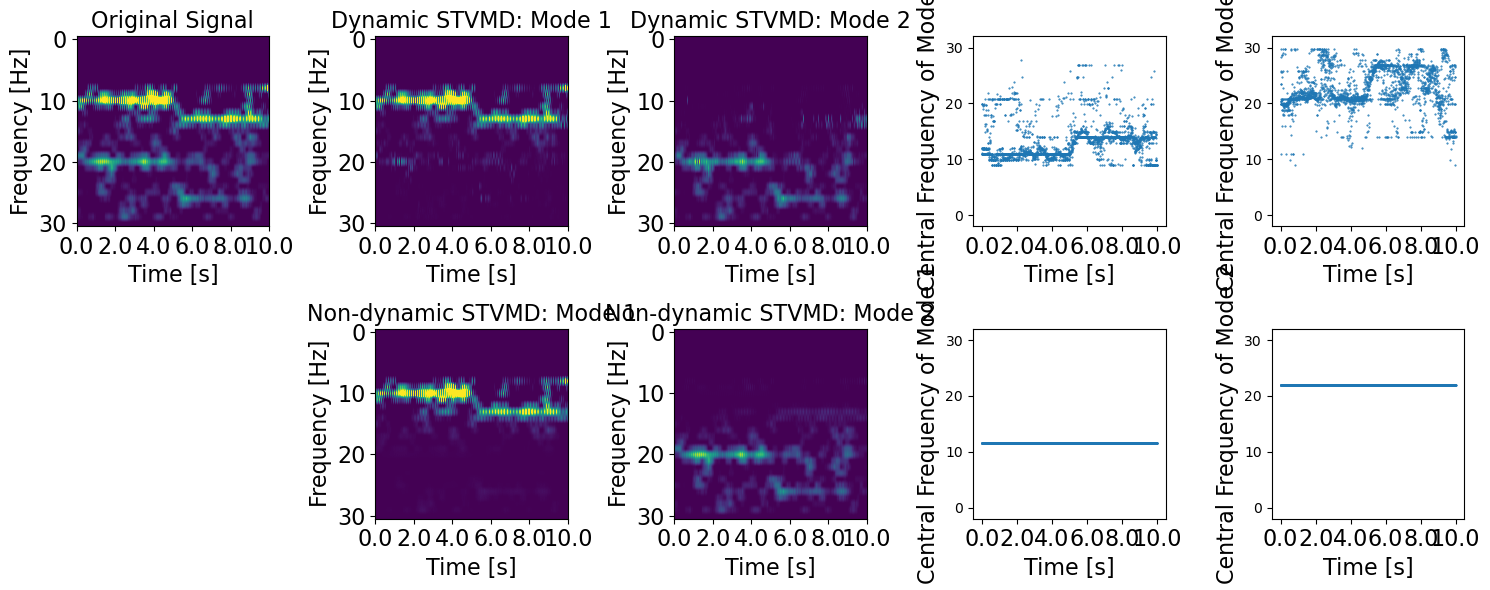

In [27]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
N = 2500
fs = 250
p_end = 31
p_step=10
scale=1
fontsize = 16
vmax =5
# f_hat_s = f_hat_s[:,:,]

axs[0, 0].imshow(np.abs(f_hat_s[0,:p_end,:]), aspect='auto', vmax=vmax)
axs[0, 0].set_xticks(np.arange(0, N+1, 2*fs))
axs[0, 0].set_xticklabels(np.arange(0, N+1, 2*fs)/fs, fontsize=fontsize)
axs[0, 0].set_yticks(np.arange(0, p_end, p_step))
axs[0, 0].set_yticklabels(np.arange(0, p_end, p_step)*scale, fontsize=fontsize)
axs[0, 0].set_xlabel('Time [s]', fontsize=fontsize)
axs[0, 0].set_ylabel('Frequency [Hz]', fontsize=fontsize)
axs[0, 0].set_title('Original Signal', fontsize=fontsize)

for idx in range(2):
    i = idx+1
    axs[0, i].imshow(np.abs(u_hat_d[0,:p_end,idx+1,:]), aspect='auto', vmax=vmax)
    axs[0, i].set_xticks(np.arange(0, N+1, 2*fs))
    axs[0, i].set_xticklabels(np.arange(0, N+1, 2*fs)/fs, fontsize=fontsize)
    axs[0, i].set_yticks(np.arange(0, p_end, p_step))
    axs[0, i].set_yticklabels(np.arange(0, p_end, p_step)*scale, fontsize=fontsize)
    axs[0, i].set_xlabel('Time [s]', fontsize=fontsize)
    axs[0, i].set_ylabel('Frequency [Hz]', fontsize=fontsize)
    if idx+1!=0:
        axs[0, i].set_title(f'Dynamic STVMD: Mode {idx+1}', fontsize=fontsize)
    else:
        axs[0, i].set_title(f'Dynamic STVMD: Residual at 0 Hz', fontsize=fontsize)

axs[0, 3].plot(w_hat_d[1].T*125, marker='.', markersize=1, linestyle='')
axs[0, 3].set_xticks(np.arange(0, N+1, 2*fs))
axs[0, 3].set_xticklabels(np.arange(0, N+1, 2*fs)/fs, fontsize=fontsize)
axs[0, 3].set_ylim(-2, 32)
axs[0, 3].set_xlabel('Time [s]', fontsize=fontsize)
axs[0, 3].set_ylabel('Central Frequency of Mode 1', fontsize=fontsize)

axs[0, 4].plot(w_hat_d[2].T*125, marker='.', markersize=1, linestyle='')
axs[0, 4].set_xticks(np.arange(0, N+1, 2*fs))
axs[0, 4].set_xticklabels(np.arange(0, N+1, 2*fs)/fs, fontsize=fontsize)
axs[0, 4].set_ylim(-2, 32)
axs[0, 4].set_xlabel('Time [s]', fontsize=fontsize)
axs[0, 4].set_ylabel('Central Frequency of Mode 2', fontsize=fontsize)

axs[1, 0].axis('off')
for idx in range(2):
    i = idx+1
    axs[1, i].imshow(np.abs(u_hat_nd[0,:p_end,idx+1,:]), aspect='auto', vmax=vmax)
    axs[1, i].set_xticks(np.arange(0, N+1, 2*fs))
    axs[1, i].set_xticklabels(np.arange(0, N+1, 2*fs)/fs, fontsize=fontsize)
    axs[1, i].set_yticks(np.arange(0, p_end, p_step))
    axs[1, i].set_yticklabels(np.arange(0, p_end, p_step)*scale, fontsize=fontsize)
    axs[1, i].set_xlabel('Time [s]', fontsize=fontsize)
    axs[1, i].set_ylabel('Frequency [Hz]', fontsize=fontsize)
    if idx+1!=0:
        axs[1, i].set_title(f'Non-dynamic STVMD: Mode {idx+1}', fontsize=fontsize)
    else:
        axs[1, i].set_title(f'Non-dynamic STVMD: Residual at 0 Hz', fontsize=fontsize)

axs[1, 3].plot(w_hat_nd[1].reshape(1,-1)*np.ones((N,1))*125, marker='.', markersize=1, linestyle='', label=['Residual', 'Mode 1', 'Mode 2'])
axs[1, 3].set_xticks(np.arange(0, N+1, 2*fs))
axs[1, 3].set_xticklabels(np.arange(0, N+1, 2*fs)/fs, fontsize=fontsize)
axs[1, 3].set_ylim(-2, 32)
axs[1, 3].set_xlabel('Time [s]', fontsize=fontsize)
axs[1, 3].set_ylabel('Central Frequency of Mode 1', fontsize=fontsize)

axs[1, 4].plot(w_hat_nd[2].reshape(1,-1)*np.ones((N,1))*125, marker='.', markersize=1, linestyle='', label=['Residual', 'Mode 1', 'Mode 2'])
axs[1, 4].set_xticks(np.arange(0, N+1, 2*fs))
axs[1, 4].set_xticklabels(np.arange(0, N+1, 2*fs)/fs, fontsize=fontsize)
axs[1, 4].set_ylim(-2, 32)
axs[1, 4].set_xlabel('Time [s]', fontsize=fontsize)
axs[1, 4].set_ylabel('Central Frequency of Mode 2', fontsize=fontsize)
# axs[1, 4].legend(loc='lower left')

plt.tight_layout()  # Adjusts subplot params so that subplots fit into the figure area.
plt.savefig('figure2.5.png', format='png')
plt.show()

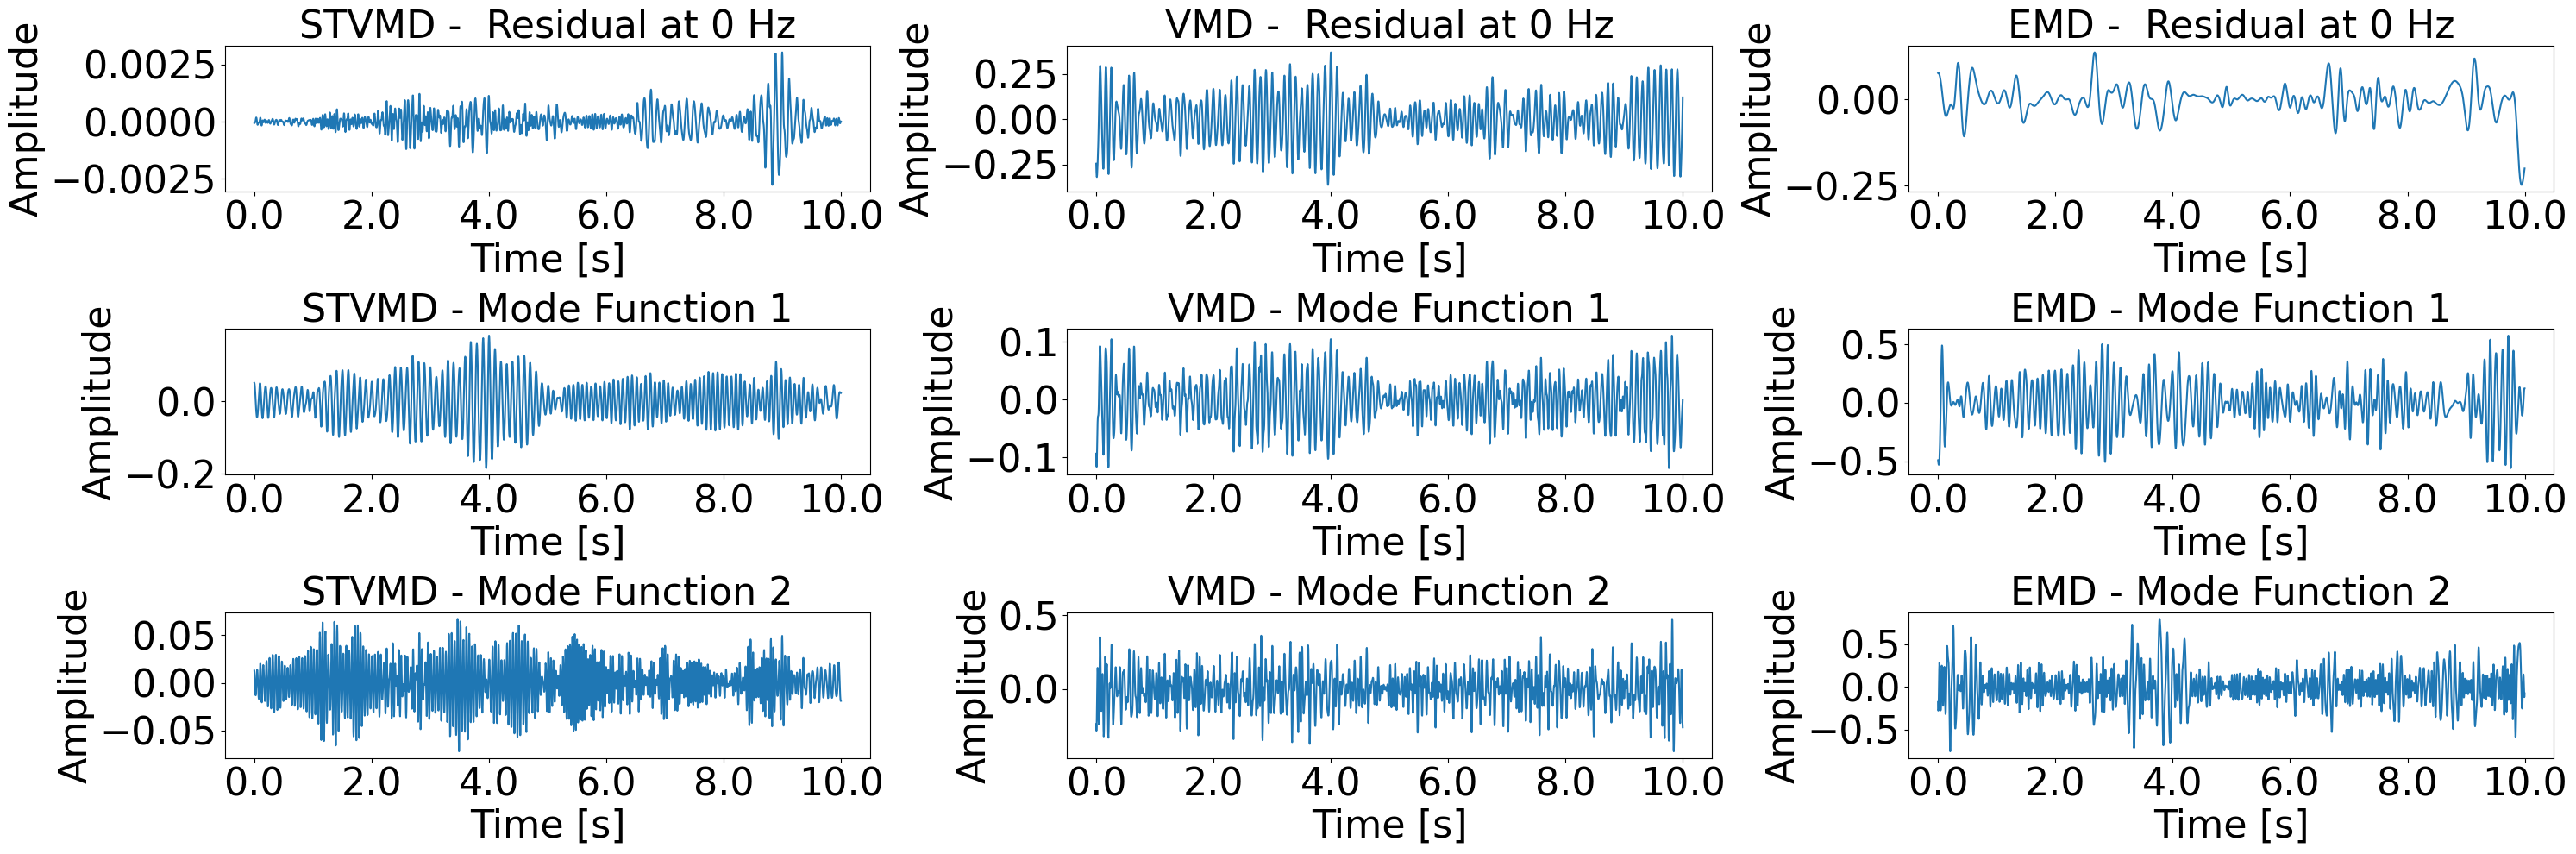

In [28]:
fontsize = 32

fig, axs = plt.subplots(3, 3, figsize=(30,10))

for i in range(3):
    axs[i, 0].plot(imf_stvmd_d[i,0,:])
    axs[i, 0].set_xticks(np.arange(0, N+1, 2*fs))
    axs[i, 0].set_xticklabels(np.arange(0, N+1, 2*fs)/fs)
    axs[i, 0].tick_params(axis='both', labelsize=fontsize)
    axs[i, 0].set_xlabel('Time [s]', fontsize=fontsize)
    axs[i, 0].set_ylabel('Amplitude', fontsize=fontsize)
    axs[i, 0].set_title(f'STVMD - {mode[i]}', fontsize=fontsize)
for i in range(3):
    axs[i, 1].plot(imf_vmd[i,0,:])
    axs[i, 1].set_xticks(np.arange(0, N+1, 2*fs))
    axs[i, 1].set_xticklabels(np.arange(0, N+1, 2*fs)/fs)
    axs[i, 1].tick_params(axis='both', labelsize=fontsize)
    axs[i, 1].set_xlabel('Time [s]', fontsize=fontsize)
    axs[i, 1].set_ylabel('Amplitude', fontsize=fontsize)
    axs[i, 1].set_title(f'VMD - {mode[i]}', fontsize=fontsize)
for i in range(3):
    axs[i, 2].plot(imf_emd[2-i,:])
    axs[i, 2].set_xticks(np.arange(0, N+1, 2*fs))
    axs[i, 2].set_xticklabels(np.arange(0, N+1, 2*fs)/fs)
    axs[i, 2].tick_params(axis='both', labelsize=fontsize)
    axs[i, 2].set_xlabel('Time [s]', fontsize=fontsize)
    axs[i, 2].set_ylabel('Amplitude', fontsize=fontsize)
    axs[i, 2].set_title(f'EMD - {mode[i]}', fontsize=fontsize)
plt.tight_layout()
plt.savefig('figure2.6.png', format='png', dpi=300)
plt.show()